<a href="https://colab.research.google.com/github/Bakana1171/daset/blob/main/Health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Améliorer la présence aux rendez-vous des patients et le support aux patients grâce aux données et à l’IA

### 1. Prise en main du jeu de données

A - Importation des librairies

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

B- Télechargement du fichier

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HealthC.xlsx to HealthC.xlsx


In [ ]:
HC = pd.read_excel('HealthC.xlsx')
HC.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-06-02 00:00:00,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-09-07 00:00:00,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


2. Évaluation de la qualité des données

In [ ]:
HC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

In [ ]:
HC['appointment_date']=pd.to_datetime(HC['appointment_date'],errors='coerce')

In [ ]:
HC['booking_date']=pd.to_datetime(HC['booking_date'],errors='coerce')

In [ ]:
HC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   appointment_id         5000 non-null   object        
 1   patient_id             5000 non-null   object        
 2   gender                 5000 non-null   object        
 3   age                    5000 non-null   int64         
 4   age_group              5000 non-null   object        
 5   appointment_type       5000 non-null   object        
 6   booking_date           5000 non-null   datetime64[ns]
 7   appointment_date       5000 non-null   datetime64[ns]
 8   appointment_day        5000 non-null   object        
 9   appointment_time       5000 non-null   object        
 10  booking_lead_days      5000 non-null   int64         
 11  previous_appointments  5000 non-null   int64         
 12  previous_no_shows      5000 non-null   int64         
 13  rem

In [ ]:
HC.describe()

,age,booking_date,appointment_date,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,5000.000000,5000,5000,5000.00000,5000.000000,5000.000000,4910.000000,4940.000000
mean,48.794800,2025-09-09 02:37:49.440000,2025-10-11 02:50:29.760000,29.63860,3.013800,0.544200,10.109572,24.189676
min,18.000000,2024-01-12 00:00:00,2025-01-01 00:00:00,0.00000,0.000000,0.000000,0.500000,2.000000
25%,33.000000,2025-04-15 00:00:00,2025-05-14 00:00:00,15.00000,2.000000,0.000000,5.300000,17.000000
50%,49.000000,2025-08-31 00:00:00,2025-09-28 00:00:00,30.00000,3.000000,0.000000,8.700000,24.000000
75%,64.000000,2026-01-24 00:00:00,2026-02-25 00:00:00,45.00000,4.000000,1.000000,13.500000,32.000000
max,80.000000,2026-12-06 00:00:00,2026-12-06 00:00:00,60.00000,11.000000,5.000000,45.000000,68.000000
std,18.138547,NaN,NaN,17.39936,1.741211,0.746832,6.590030,10.863184


In [ ]:
HC.isna().sum()

,0
appointment_id,0
patient_id,0
gender,0
age,0
age_group,0
appointment_type,0
booking_date,0
appointment_date,0
appointment_day,0
appointment_time,0


In [ ]:
HC.duplicated().sum()

np.int64(0)

In [ ]:
HC['reminder_channel'] = HC['reminder_channel'].fillna('Autres')

In [ ]:
Distance_mean = HC['distance_to_clinic_km'].mean()
Distance_mean

np.float64(10.109572301425661)

In [ ]:
HC['distance_to_clinic_km'] = HC['distance_to_clinic_km'].fillna(10.11)

In [ ]:
Time_mean = HC['waiting_time_minutes'].mean()
Time_mean

np.float64(24.189676113360324)

In [ ]:
HC['waiting_time_minutes'] = HC['waiting_time_minutes'].fillna(28.0)

In [ ]:
HC.isna().sum()

,0
appointment_id,0
patient_id,0
gender,0
age,0
age_group,0
appointment_type,0
booking_date,0
appointment_date,0
appointment_day,0
appointment_time,0


Commentaire :  Les données du HealthConnect Experience Lab ne présentaient aucun doublon, mais comportaient des valeurs manquantes. Plus précisément :

1366 valeurs manquantes sur reminder channel, remplacées par la modalité autres.

90 valeurs manquantes sur distance to clinic, remplacées par la moyenne de 10,11 km.

60 valeurs manquantes sur waiting time minutes, remplacées par la moyenne de 28 minutes.

Après ce nettoyage, le jeu de données est désormais complet, cohérent et prêt pour l’analyse.

## 3. Exploration des données (EDA)

Distribution des présences vs absences (variable cible probable pour la suite du projet).

Distribution des résultats de rendez-vous:
appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

Pourcentage des résultats de rendez-vous:
appointment_outcome
No-Show      48.46
Attended     46.28
Cancelled     5.26
Name: proportion, dtype: float64


/tmp/ipykernel_875/354902304.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette='viridis')


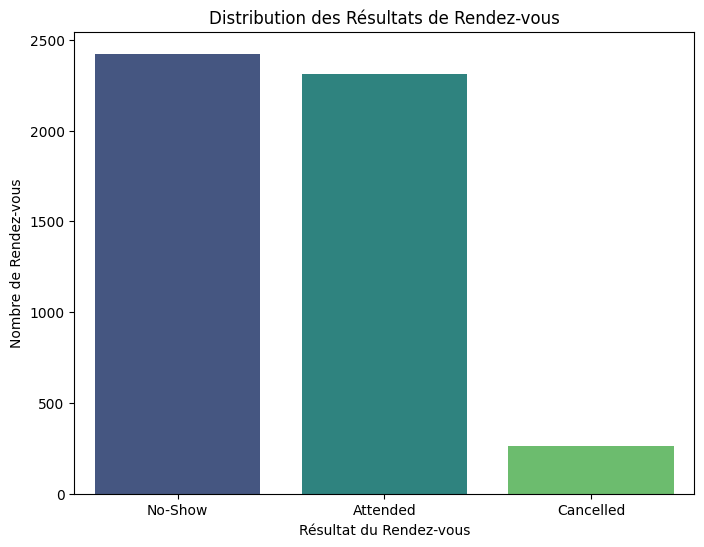

In [ ]:
outcome_counts = HC['appointment_outcome'].value_counts()
outcome_percentages = HC['appointment_outcome'].value_counts(normalize=True) * 100

print("Distribution des résultats de rendez-vous:")
print(outcome_counts)
print("\nPourcentage des résultats de rendez-vous:")
print(outcome_percentages)

fig = plt.figure(figsize=(8, 6))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette='viridis')
plt.title('Distribution des Résultats de Rendez-vous')
plt.xlabel('Résultat du Rendez-vous')
plt.ylabel('Nombre de Rendez-vous')
plt.show()

Impact du délai de réservation (booking_lead_days) sur le résultat du rendez-vous

/tmp/ipykernel_875/1720413640.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='appointment_outcome', y='booking_lead_days', data=HC, palette='coolwarm')


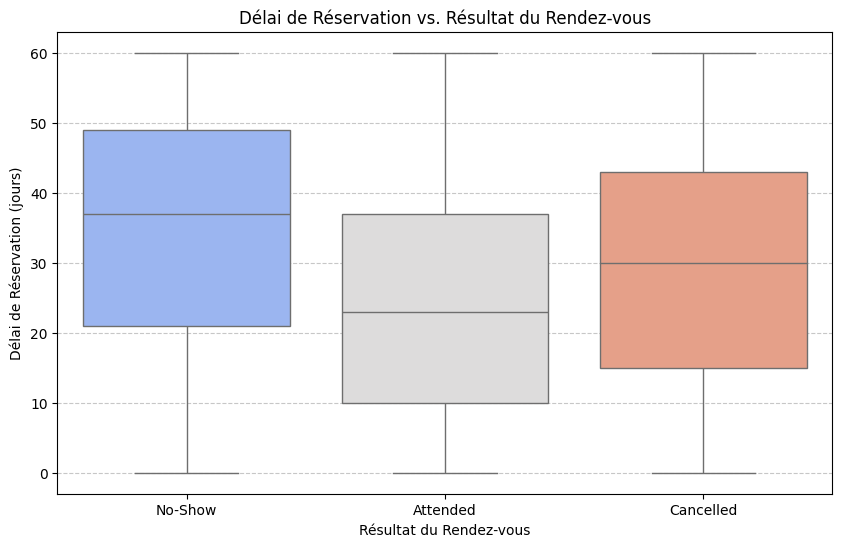

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='appointment_outcome', y='booking_lead_days', data=HC, palette='coolwarm')
plt.title('Délai de Réservation vs. Résultat du Rendez-vous')
plt.xlabel('Résultat du Rendez-vous')
plt.ylabel('Délai de Réservation (jours)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Impact de la distance à la clinique (distance_to_clinic_km) sur le résultat du rendez-vous

/tmp/ipykernel_875/2482514591.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='appointment_outcome', y='distance_to_clinic_km', data=HC, palette='viridis')


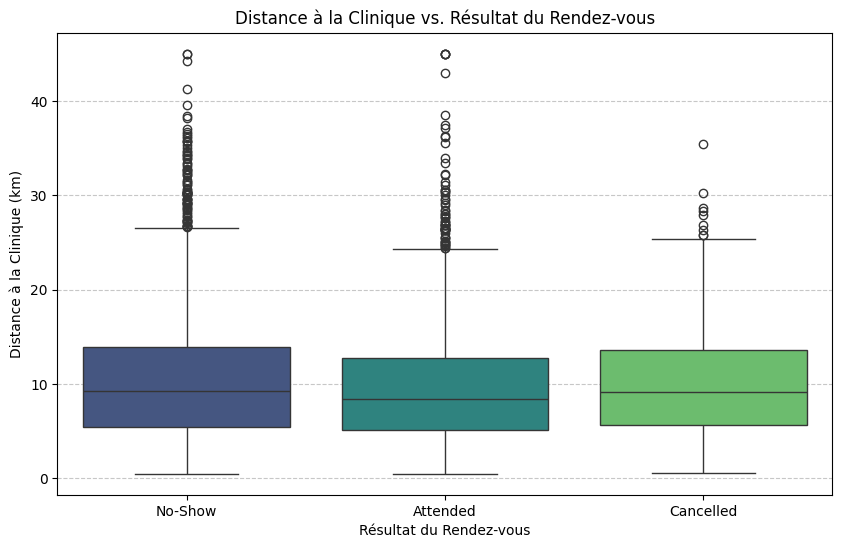

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='appointment_outcome', y='distance_to_clinic_km', data=HC, palette='viridis')
plt.title('Distance à la Clinique vs. Résultat du Rendez-vous')
plt.xlabel('Résultat du Rendez-vous')
plt.ylabel('Distance à la Clinique (km)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Impact du nombre de no-shows précédents (previous_no_shows) sur le résultat du rendez-vous

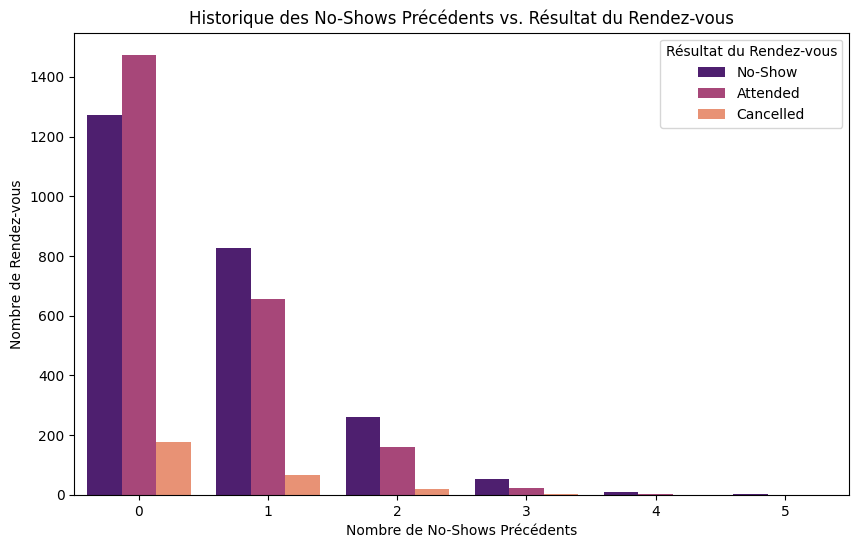

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='previous_no_shows', hue='appointment_outcome', data=HC, palette='magma')
plt.title('Historique des No-Shows Précédents vs. Résultat du Rendez-vous')
plt.xlabel('Nombre de No-Shows Précédents')
plt.ylabel('Nombre de Rendez-vous')
plt.legend(title='Résultat du Rendez-vous')
plt.show()

Impact de l'envoi de rappel (reminder_sent) sur le résultat du rendez-vous

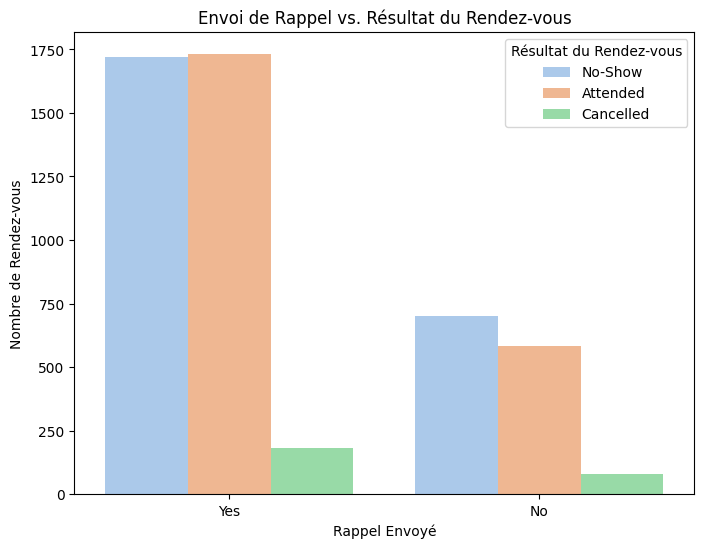

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='reminder_sent', hue='appointment_outcome', data=HC, palette='pastel')
plt.title('Envoi de Rappel vs. Résultat du Rendez-vous')
plt.xlabel('Rappel Envoyé')
plt.ylabel('Nombre de Rendez-vous')
plt.legend(title='Résultat du Rendez-vous')
plt.show()

Impact de l'âge (age) sur le résultat du rendez-vous

/tmp/ipykernel_875/2905626070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='appointment_outcome', y='age', data=HC, palette='plasma')


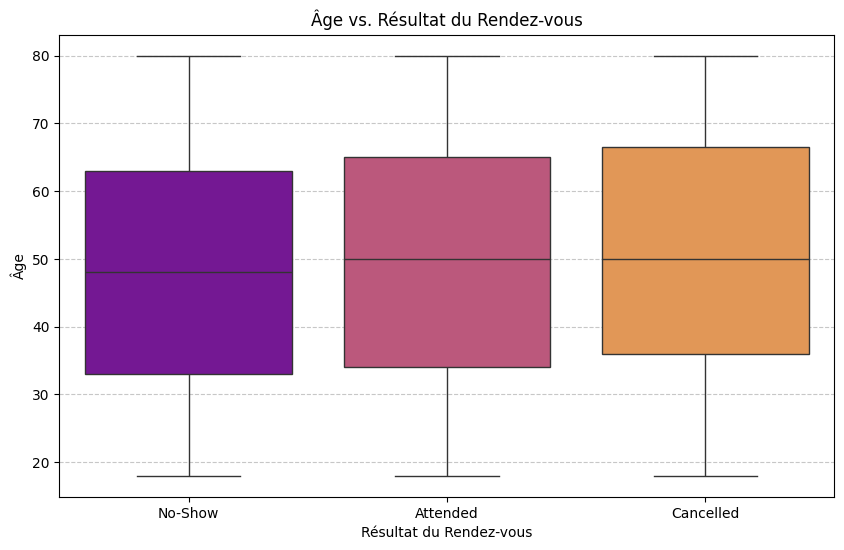

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='appointment_outcome', y='age', data=HC, palette='plasma')
plt.title('Âge vs. Résultat du Rendez-vous')
plt.xlabel('Résultat du Rendez-vous')
plt.ylabel('Âge')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Impact du jour du rendez-vous (appointment_day) sur le résultat du rendez-vous

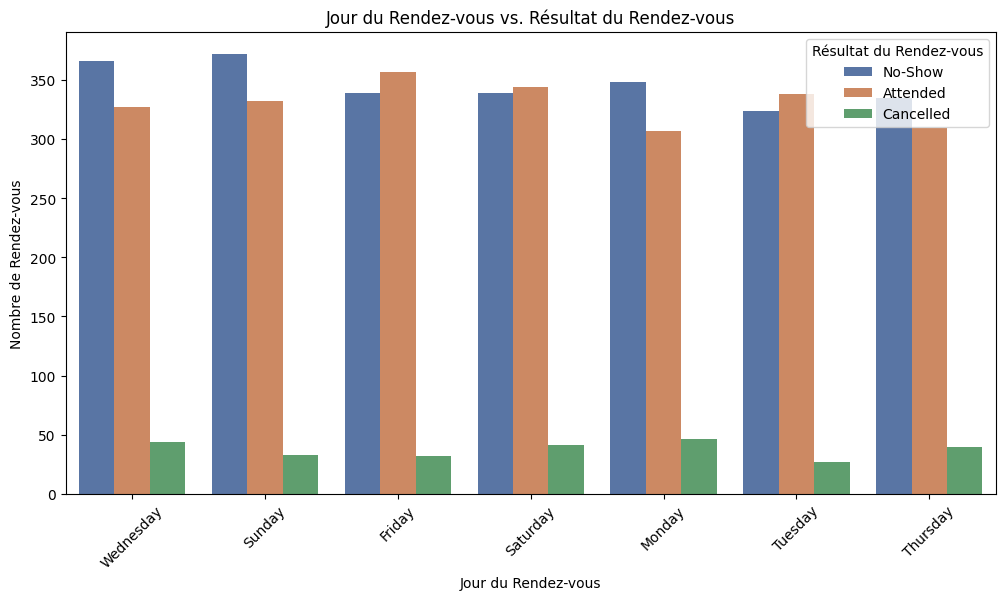

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='appointment_day', hue='appointment_outcome', data=HC, palette='deep', order=HC['appointment_day'].value_counts().index)
plt.title('Jour du Rendez-vous vs. Résultat du Rendez-vous')
plt.xlabel('Jour du Rendez-vous')
plt.ylabel('Nombre de Rendez-vous')
plt.legend(title='Résultat du Rendez-vous')
plt.xticks(rotation=45)
plt.show()